<a href="https://colab.research.google.com/github/ak07-aiml/ml-leakage-pipeline--Arul-Kumaran-/blob/main/Regression_Predicting_Values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Intercept: 1.658885327981892
Coefficients:
area_sqft: 0.049198575781706284
num_bedrooms: 9.973370682486316
age_years: -0.500086699984271

Actual vs Predicted:
       Actual   Predicted
0   92.984115   89.407696
1  112.409908  113.711200
2   79.523452   81.231316
3   88.428852   98.288336
4  139.080647  135.617300

Evaluation Metrics:
MAE: 4.139383549921054
RMSE: 4.963948207737393
R²: 0.9835564547174395


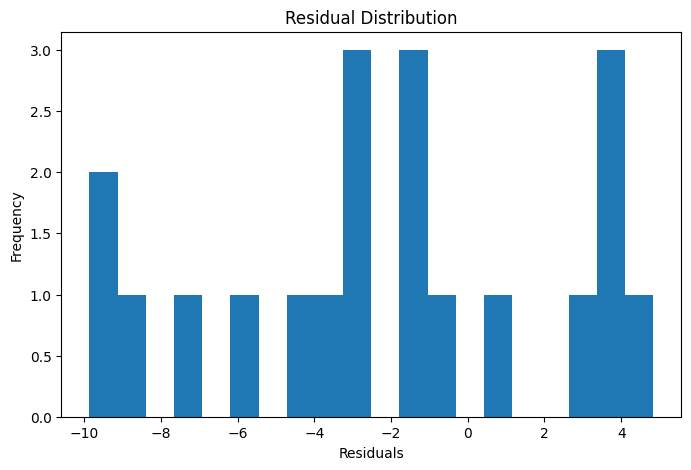

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------
# Task 1: Create Dataset
# ---------------------------

np.random.seed(42)

n = 100

data = {
    "area_sqft": np.random.randint(500, 3000, n),
    "num_bedrooms": np.random.randint(1, 5, n),
    "age_years": np.random.randint(0, 30, n)
}

df = pd.DataFrame(data)

# Create target with some realistic relationship + noise
df["price_lakhs"] = (
    df["area_sqft"] * 0.05 +
    df["num_bedrooms"] * 10 -
    df["age_years"] * 0.5 +
    np.random.normal(0, 5, n)
)

# Features & Target
X = df[["area_sqft", "num_bedrooms", "age_years"]]
y = df["price_lakhs"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Intercept & Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef}")

# Predictions
y_pred = model.predict(X_test)

# Show first 5 actual vs predicted
print("\nActual vs Predicted:")
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
print(comparison.head())

# ---------------------------
# Task 2: Evaluation Metrics
# ---------------------------

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nEvaluation Metrics:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Comments:
# MAE shows the average absolute error in predictions.
# RMSE penalizes larger errors more heavily than MAE.
# R² indicates how well the model explains variance (closer to 1 is better).

# ---------------------------
# Task 3: Residual Analysis
# ---------------------------

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Comments:
# Residual = Actual - Predicted value.
# A roughly symmetric, bell-shaped histogram suggests the model errors are normally distributed.
# If skewed or wide → model may have bias or missing features.